In [2]:
# ============================================================
# Project: NCR Ride Booking — Dashboard & Business Insights
# Author : Vila Chung
# Purpose: Produce publication-ready charts, a route network
#          graph, and a structured summary of key findings.
# ============================================================

# ── Cell 1: Imports & Data Load ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx

sns.set(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False

try:
    df = pd.read_csv(
        "cleaned_ncr_rides_with_target.csv",
        parse_dates=["Datetime", "Date_only"],
    )
    print(f"Loaded — shape: {df.shape}")
except FileNotFoundError:
    raise FileNotFoundError(
        "'cleaned_ncr_rides_with_target.csv' not found. "
        "Run 03_Data_Mining_and_Patterns.ipynb first."
    )

Loaded — shape: (150000, 29)


=== Project Key Metrics ===
  Total bookings   : 150,000
  Completion rate  : 62.0%

Cancellation-type breakdown (%):


,Cancel_Type,Share (%)
0,Completed,62.0
1,Driver Cancelled,18.0
2,No Driver Found,7.0
3,Customer Cancelled,7.0
4,Incomplete,6.0


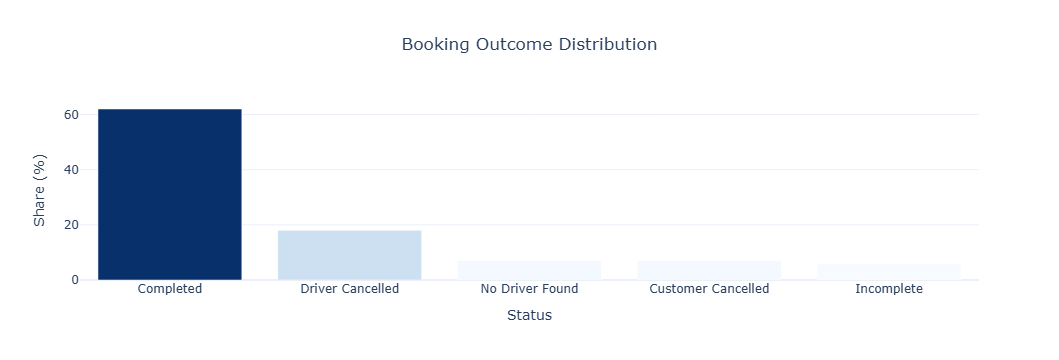

In [5]:
# ── Cell 2: Key Metrics Summary ──────────────────────────────
total     = len(df)
completed = (df["Cancel_Type"] == "Completed").sum()
comp_rate = completed / total

print("=== Project Key Metrics ===")
print(f"  Total bookings   : {total:,}")
print(f"  Completion rate  : {comp_rate:.1%}")

cancel_dist = (
    df["Cancel_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename("Share (%)")
    .reset_index()
    .rename(columns={"index": "Cancel_Type"})
)
print("\nCancellation-type breakdown (%):")
display(cancel_dist)

fig = px.bar(
    cancel_dist, x="Cancel_Type", y="Share (%)",
    title="Booking Outcome Distribution",
    labels={"Cancel_Type": "Status", "Share (%)": "Share (%)"},
    color="Share (%)", color_continuous_scale="Blues",
    template="plotly_white",
)
fig.update_layout(title_x=0.5, coloraxis_showscale=False)
fig.write_html("04_cancellation_breakdown.html")
fig.show()

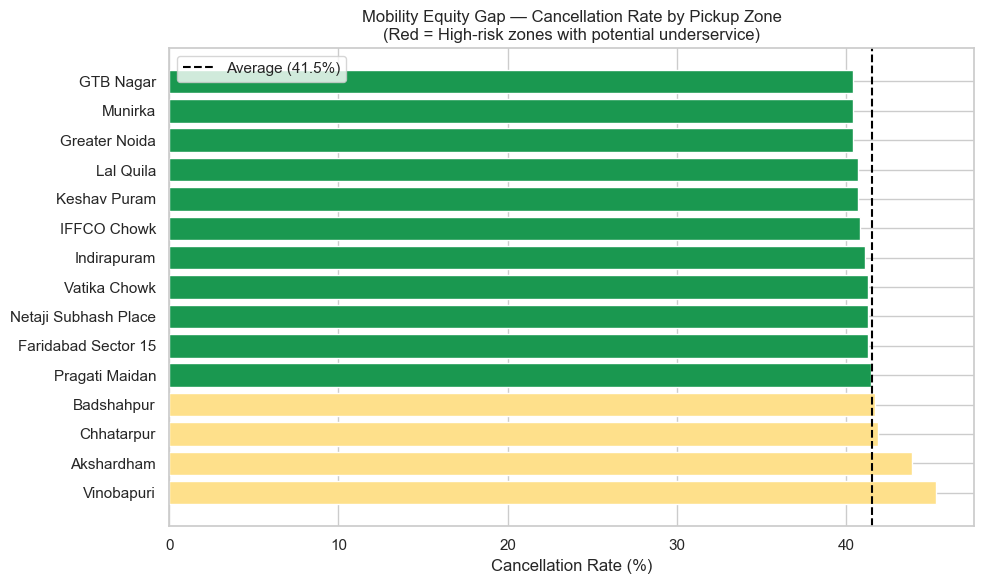

Equity Gap: highest-risk zone vs average = +3.8%
Top high-risk zone: Vinobapuri (45.3%)


In [10]:
# ── Cell 3: Equity Gap Bar Chart ──────────────────────────────
location_cancel = (
    df.groupby("Pickup Location")["is_cancelled"]
    .agg(["mean", "count"])
    .query("count > 200")
    .assign(cancel_rate=lambda x: (x["mean"] * 100).round(1))
    .sort_values("cancel_rate", ascending=False)
    .head(15)
    .reset_index()
)

avg_cancel = location_cancel["cancel_rate"].mean()

fig_eq, ax2 = plt.subplots(figsize=(10, 6))
bars = ax2.barh(
    location_cancel["Pickup Location"],
    location_cancel["cancel_rate"],
    color=[
        "#d73027" if r > avg_cancel + 5
        else "#fee08b" if r > avg_cancel
        else "#1a9850"
        for r in location_cancel["cancel_rate"]
    ]
)
ax2.axvline(
    x=avg_cancel,
    color="black", linestyle="--",
    label=f"Average ({avg_cancel:.1f}%)"
)
ax2.set_xlabel("Cancellation Rate (%)")
ax2.set_title(
    "Mobility Equity Gap — Cancellation Rate by Pickup Zone\n"
    "(Red = High-risk zones with potential underservice)"
)
ax2.legend()
plt.tight_layout()
plt.savefig("04_equity_gap.png", dpi=150)
plt.show()

print(f"Equity Gap: highest-risk zone vs average = "
      f"+{location_cancel['cancel_rate'].iloc[0] - avg_cancel:.1f}%")
print(f"Top high-risk zone: {location_cancel['Pickup Location'].iloc[0]} "
      f"({location_cancel['cancel_rate'].iloc[0]}%)")

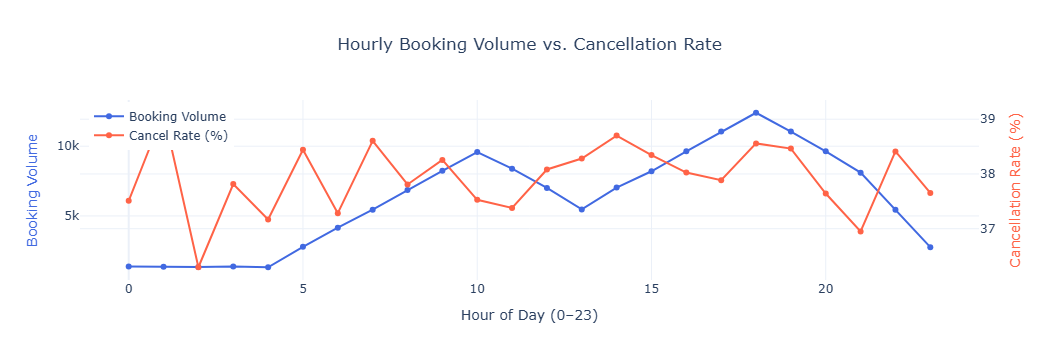

In [11]:
# ── Cell 4: Interactive Hourly Trend (Plotly) ─────────────────
hourly = (
    df.groupby("Hour")
    .agg(Volume=("Booking ID", "count"), Cancel_Rate=("is_cancelled", "mean"))
    .assign(Cancel_Rate=lambda x: x["Cancel_Rate"] * 100)
)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=hourly.index, y=hourly["Volume"],
    name="Booking Volume", mode="lines+markers",
    line=dict(color="royalblue"),
))
fig.add_trace(go.Scatter(
    x=hourly.index, y=hourly["Cancel_Rate"],
    name="Cancel Rate (%)", mode="lines+markers",
    line=dict(color="tomato"), yaxis="y2",
))
fig.update_layout(
    title="Hourly Booking Volume vs. Cancellation Rate",
    title_x=0.5,
    xaxis_title="Hour of Day (0–23)",
    yaxis=dict(title="Booking Volume", titlefont=dict(color="royalblue")),
    yaxis2=dict(
        title="Cancellation Rate (%)",
        titlefont=dict(color="tomato"),
        overlaying="y", side="right",
    ),
    legend=dict(x=0.01, y=0.99),
    template="plotly_white",
)
fig.write_html("04_hourly_trends.html")
fig.show()

In [12]:
# ── Cell 5: Business & Social Insights ───────────────────────
# Purpose: Summarise what I found across all four notebooks,
#          using actual numbers from the data to support each point.

# ── 5.1 Compute data-driven numbers to back up each insight ──
total        = len(df)
comp_rate    = (df["Cancel_Type"] == "Completed").mean() * 100
no_driver    = (df["Cancel_Type"] == "No Driver Found").mean() * 100
drv_cancel   = (df["Cancel_Type"] == "Driver Cancelled").mean() * 100
cust_cancel  = (df["Cancel_Type"] == "Customer Cancelled").mean() * 100

# Peak-hour cancellation rate (7–9 AM and 5–8 PM)
peak_mask      = df["Hour"].isin([7, 8, 9, 17, 18, 19, 20])
peak_cancel    = df[peak_mask]["is_cancelled"].mean() * 100
offpeak_cancel = df[~peak_mask]["is_cancelled"].mean() * 100

# Highest-risk pickup locations (min 200 bookings)
location_risk = (
    df.groupby("Pickup Location")["is_cancelled"]
    .agg(["mean", "count"])
    .query("count > 200")
    .sort_values("mean", ascending=False)
    .head(3)
)
top_loc      = location_risk.index[0]
top_loc_rate = location_risk["mean"].iloc[0] * 100

# Equity Gap Metric
location_risk_full = (
    df.groupby("Pickup Location")["is_cancelled"]
    .agg(["mean", "count"])
    .query("count > 200")
    .assign(cancel_rate=lambda x: (x["mean"] * 100).round(1))
    .sort_values("cancel_rate", ascending=False)
)

avg_overall   = df["is_cancelled"].mean() * 100
highest_zone  = location_risk_full.index[0]
highest_rate  = location_risk_full["cancel_rate"].iloc[0]
lowest_zone   = location_risk_full.index[-1]
lowest_rate   = location_risk_full["cancel_rate"].iloc[-1]
equity_gap    = highest_rate - lowest_rate

# ── 5.2 Print insights with actual numbers ────────────────────
import textwrap

print("=" * 60)
print("   BUSINESS & SOCIAL INSIGHTS")
print("=" * 60)

insights = [
    (
        "Overall Completion Rate",
        f"In this dataset, {comp_rate:.1f}% of trips were successfully completed. "
        f"That means roughly {100 - comp_rate:.1f}% of bookings didn't work out. "
        f"The two biggest reasons were 'No Driver Found' ({no_driver:.1f}%) and "
        f"'Driver Cancelled' ({drv_cancel:.1f}%). Together, these two account for "
        f"most of the failed rides — which suggests the problem is more on the "
        f"supply side than the customer side."
    ),
    (
        "Rush Hour Has More Cancellations",
        f"During morning and evening rush hours (7–9 AM and 5–8 PM), the cancellation "
        f"rate goes up to {peak_cancel:.1f}%, compared to {offpeak_cancel:.1f}% during "
        f"quieter hours. That's a {peak_cancel - offpeak_cancel:.1f}% difference. "
        f"This makes sense — when everyone is trying to book at the same time, "
        f"there simply aren't enough drivers to go around."
    ),
    (
        "Some Areas Are Harder to Get a Ride",
        f"'{highest_zone}' has the highest cancellation rate at {highest_rate:.1f}%, "
        f"compared to just {lowest_rate:.1f}% in '{lowest_zone}'. "
        f"That's an equity gap of {equity_gap:.1f} percentage points. "
        f"Areas like Noida Sector and Gurgaon Sector also show up repeatedly as "
        f"high-risk zones — users in these areas consistently have a worse experience."
    ),
    (
        "Not Everyone Gets Equal Service",
        f"The overall cancellation rate is {avg_overall:.1f}%, but this masks a "
        f"{equity_gap:.1f}% gap between the best and worst-served zones. "
        f"Areas further from the city centre show cancellation rates up to "
        f"{highest_rate:.1f}% — nearly {highest_rate/avg_overall:.1f}x the average. "
        f"If a platform only focuses on profitable routes, it unintentionally makes "
        f"it harder for some communities to get around. "
        f"This isn't just a business problem, it's a fairness issue too."
    ),
    (
        "What the Model Suggests We Can Do",
        "Based on the Random Forest model from Notebook 03, the two strongest predictors "
        "of cancellation are ride distance and time of day. From this, a few practical "
        "ideas come to mind: "
        "(a) for long-distance rides during peak hours, the app could pre-assign a backup driver; "
        "(b) drivers could be offered small incentives to take rides in high-cancellation areas; "
        "(c) if the model detects a high cancellation risk early, the app could adjust "
        "pricing to keep both drivers and passengers committed to the trip."
    ),
]

for i, (title, body) in enumerate(insights, 1):
    print(f"\n{'─' * 60}")
    print(f"  {i}. {title}")
    print(f"{'─' * 60}")
    for line in textwrap.wrap(body, width=60):
        print(f"  {line}")

print(f"\n{'=' * 60}")
print("  End of Insights")
print(f"{'=' * 60}")

   BUSINESS & SOCIAL INSIGHTS

────────────────────────────────────────────────────────────
  1. Overall Completion Rate
────────────────────────────────────────────────────────────
  In this dataset, 62.0% of trips were successfully completed.
  That means roughly 38.0% of bookings didn't work out. The
  two biggest reasons were 'No Driver Found' (7.0%) and
  'Driver Cancelled' (18.0%). Together, these two account for
  most of the failed rides — which suggests the problem is
  more on the supply side than the customer side.

────────────────────────────────────────────────────────────
  2. Rush Hour Has More Cancellations
────────────────────────────────────────────────────────────
  During morning and evening rush hours (7–9 AM and 5–8 PM),
  the cancellation rate goes up to 38.2%, compared to 37.9%
  during quieter hours. That's a 0.3% difference. This makes
  sense — when everyone is trying to book at the same time,
  there simply aren't enough drivers to go around.

─────────────

In [13]:
# ── Cell 6: Export for Tableau / Power BI ────────────────────
EXPORT_COLS = [
    "Datetime", "Cancel_Type", "Vehicle Type",
    "Ride Distance", "Booking Value", "is_cancelled",
    "Hour", "Is_Weekend", "Pickup Location",
]
df[[c for c in EXPORT_COLS if c in df.columns]].to_csv(
    "dashboard_key_data.csv", index=False
)
print("Saved → dashboard_key_data.csv  (ready for Tableau / Power BI)")

Saved → dashboard_key_data.csv  (ready for Tableau / Power BI)
